## Overview:Online Store Orders (Real-World Project)
In this final day, you'll combine everything you’ve learned into an end-to-end mini project using Pandas.

We'll perform:

→ Data cleaning

→ Analysis & grouping

→ Visualization

→ Saving the results

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.DataFrame({
 'OrderID': [1, 2, 3, 4, 5, 6],
 'Product': ['Pen', 'Notebook', 'Pen', 'Pencil', 'Pen', 'Notebook'],
 'Quantity': [2, 1, 4, 3, 1, 2],
 'Price': [5, 15, 5, 3, 5, 15],
 'Region': ['East', 'West', 'East', 'East', 'West', 'West']
})

orders['Total'] = orders['Quantity'] * orders['Price']

In [23]:
orders          # Step 0 -> Create datasets


,OrderID,Product,Quantity,Price,Region,Total
0,1,Pen,2,5,East,10
1,2,Notebook,1,15,West,15
2,3,Pen,4,5,East,20
3,4,Pencil,3,3,East,9
4,5,Pen,1,5,West,5
5,6,Notebook,2,15,West,30


In [4]:
# Step 1: Cleaning & Checking Data
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   6 non-null      int64 
 1   Product   6 non-null      object
 2   Quantity  6 non-null      int64 
 3   Price     6 non-null      int64 
 4   Region    6 non-null      object
 5   Total     6 non-null      int64 
dtypes: int64(4), object(2)
memory usage: 420.0+ bytes


,0
OrderID,0
Product,0
Quantity,0
Price,0
Region,0
Total,0


In [6]:
# Step 2: Analyzing Data

# -> Total sales per region:

region_sales = orders.groupby('Region')['Total'].sum()
print(region_sales)



Region
East    39
West    50
Name: Total, dtype: int64


In [7]:
# -> Most sold product:

product_sales = orders.groupby('Product')['Quantity'].sum()
print(product_sales)

Product
Notebook    3
Pen         7
Pencil      3
Name: Quantity, dtype: int64


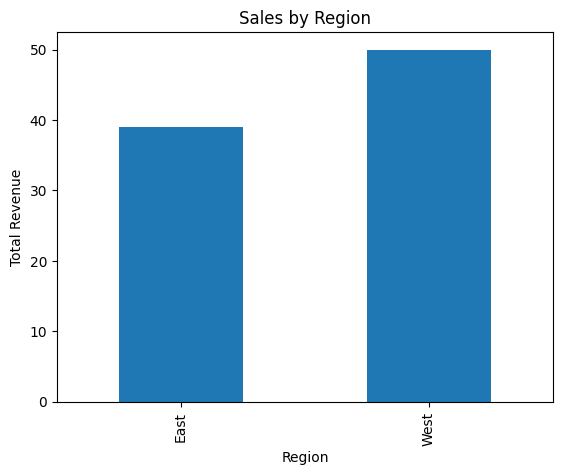

In [9]:
# Step 3: Visualization

region_sales.plot(kind='bar', title='Sales by Region')
plt.ylabel('Total Revenue')
plt.show()



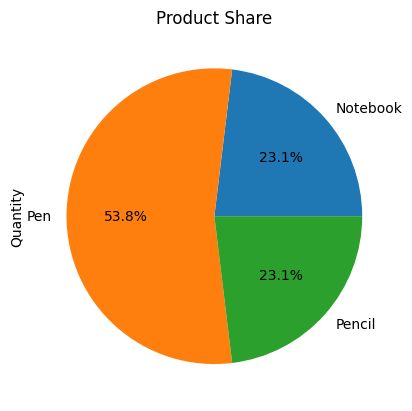

In [10]:
product_sales.plot(kind='pie', autopct='%1.1f%%', title='Product Share')   # Show the data Using Pie Chart
plt.show()

In [37]:
# Step 4: Performance Tips
# → Avoid df.iterrows() in most cases (slow)
# → Use vectorized operations:

orders['Total'] = orders['Quantity'] * orders['Price'] # Fast & efficient

In [38]:
orders['Total']

,Total
0,10
1,15
2,20
3,9
4,5
5,30


In [39]:
orders[['Price', 'Quantity', 'Total']]

,Price,Quantity,Total
0,5,2,10
1,15,1,15
2,5,4,20
3,3,3,9
4,5,1,5
5,15,2,30


In [28]:
orders.shape

(6, 6)

In [33]:
print(orders['Quantity'],orders['Price'],orders['Total'])

0    2
1    1
2    4
3    3
4    1
5    2
Name: Quantity, dtype: int64 0     5
1    15
2     5
3     3
4     5
5    15
Name: Price, dtype: int64 0    10
1    15
2    20
3     9
4     5
5    30
Name: Total, dtype: int64


In [15]:
# Step 5: Saving Results
# Save summary to CSV, Excel, and JSON:

region_sales.to_csv('region_sales.csv')
product_sales.to_excel('product_sales.xlsx')
orders.to_json('orders.json', orient='records')